Text(0, 0.5, 'Rc')

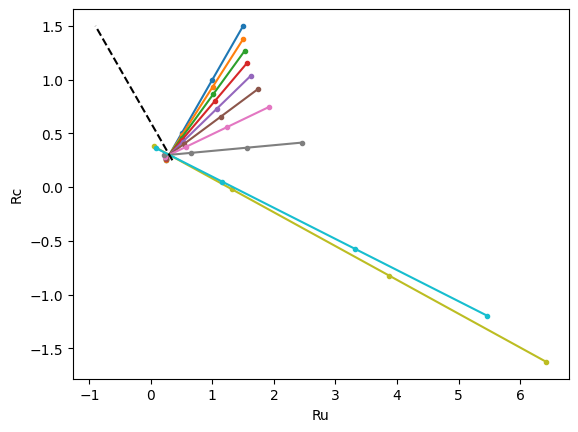

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


a = 0.5
b = 0.5
m = 0.3
A = np.array([[1, 0], [a, -b]])
D = np.array([[0, m]])

Rc0 = np.array([1., 1.])
pfr = np.array([0.25, 0.5, 1., 1.5])   # K points

alpha = 0.01

n_iter = 100

Ru_data, Rc_data = {}, {}

# Initial guess (K, 2)
Ru = pfr[:, None] * Rc0
Rc = pfr[:, None] * Rc0

# True solution
Ru_sol = ((a - 1) * Rc0[1] * pfr + m) / b

#Ru[:, 1] = Ru_sol * 1.5
#Ru[:, 1] = Ru_sol + 0.1

#Ru[:, 1] /= 50
#Rc[:, 1] *= 50

Ru_data[0] = Ru.copy()
Rc_data[0] = Rc.copy()

for n in range(1, n_iter):
    # Crude regression: fit lines Ru_i = a_i + b_i * Rc_i
    a, b = np.zeros(2), np.zeros(2)
    for i in range(2):
        coef = np.polyfit(Rc[:, i], Ru[:, i], 1)
        b[i], a[i] = coef[0], coef[1]
    
    # Choose Ru_hat
    Ru_hat = np.column_stack(
        [a + b * Rc_ for Rc_ in (Rc0[:, None] * pfr).T]).T
    
    # "Simulation"
    Rc_hat = Ru_hat @ A.T + D
    
    # Step
    Ru += alpha * (Ru_hat - Ru)
    Rc += alpha * (Rc_hat - Rc)

    Ru_data[n] = Ru.copy()
    Rc_data[n] = Rc.copy()

plt.figure()
for n in range(0, n_iter, 10):
#for n in range(0, 20):
    Ru = Ru_data[n]
    Rc = Rc_data[n]
    plt.plot(Ru[:, 1], Rc[:, 1], '.-')
plt.plot(Ru_sol, Rc0[1] * pfr, 'k--')
plt.xlabel('Ru')
plt.ylabel('Rc')
#plt.xlim(0, 1)
#plt.ylim(0, 2)


In [111]:
Rc_data[4]

array([[0.25      , 0.25318906],
       [0.5       , 0.51913436],
       [1.        , 1.05102497],
       [1.5       , 1.58291558]])

In [80]:
a_ = 1.5
b_ = 0.9
m_ = -0.1
x = ((a_ - 1) * Rc0[1] * pfr + m_) / b_
Ru[:, 1] = x
A_ = np.array([[1, 0], [a_, -b_]])
D_ = np.array([[0, m_]])
Rc_ = Ru @ A_.T + D_
print(Ru)
print(Rc_)

[[0.25       0.02777778]
 [0.5        0.16666667]
 [1.         0.44444444]
 [1.5        0.72222222]]
[[0.25 0.25]
 [0.5  0.5 ]
 [1.   1.  ]
 [1.5  1.5 ]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = -1.0
b = 0.8
d = 0.1
c01 = 0.25
c02 = 1.5

# Initial state: (u1, c1, u2, c2)
state0 = np.array([0.25, 0.25, 1.5, 1.5])

# Integration settings
t_max = 50.0
dt = 0.0001
n_steps = int(t_max / dt) + 1
times = np.linspace(0, t_max, n_steps)

# Storage arrays
states = np.zeros((n_steps, 4))
states[0] = state0

def derivatives(state):
    u1, c1, u2, c2 = state
    delta_u = u2 - u1
    delta_c = c2 - c1

    # Protect against division by zero
    if abs(delta_c) < 1e-12:
        raise ZeroDivisionError("c2 and c1 became equal (singularity).")

    u1_hat = u1 + ((c01 - c1) / delta_c) * delta_u
    u2_hat = u2 + ((c02 - c2) / delta_c) * delta_u

    c1_hat = a * u1_hat + b * c01 + d
    c2_hat = a * u2_hat + b * c02 + d

    du1_dt = u1_hat - u1
    dc1_dt = c1_hat - c1
    du2_dt = u2_hat - u2
    dc2_dt = c2_hat - c2

    return np.array([du1_dt, dc1_dt, du2_dt, dc2_dt])

# Simple Euler integration
for k in range(1, n_steps):
    states[k] = states[k - 1] + dt * derivatives(states[k - 1])

# Extract trajectories
u1_traj, c1_traj, u2_traj, c2_traj = states.T
delta_c_traj = c2_traj - c1_traj

# Plot u trajectories
plt.figure()
#plt.plot(times, u1_traj, label="u1")
#plt.plot(times, u2_traj, label="u2")
plt.plot(times, u2_traj - u1_traj, label="u2-u1")
plt.xlabel("Time")
plt.ylabel("u-values")
plt.legend()
plt.title("Trajectories of u1 and u2")
plt.show()

# Plot c trajectories
plt.figure()
#plt.plot(times, c1_traj, label="c1")
#plt.plot(times, c2_traj, label="c2")
plt.plot(times, c2_traj - c1_traj, label="c2-c1")
plt.xlabel("Time")
plt.ylabel("c-values")
plt.legend()
plt.title("Trajectories of c1 and c2")
plt.show()

# Report final state and minimum delta_c
final_state = states[-1]
min_delta_c = np.min(delta_c_traj)

print("Final state (u1, c1, u2, c2):", final_state)
print("Minimum value of (c2 - c1) encountered:", min_delta_c)

